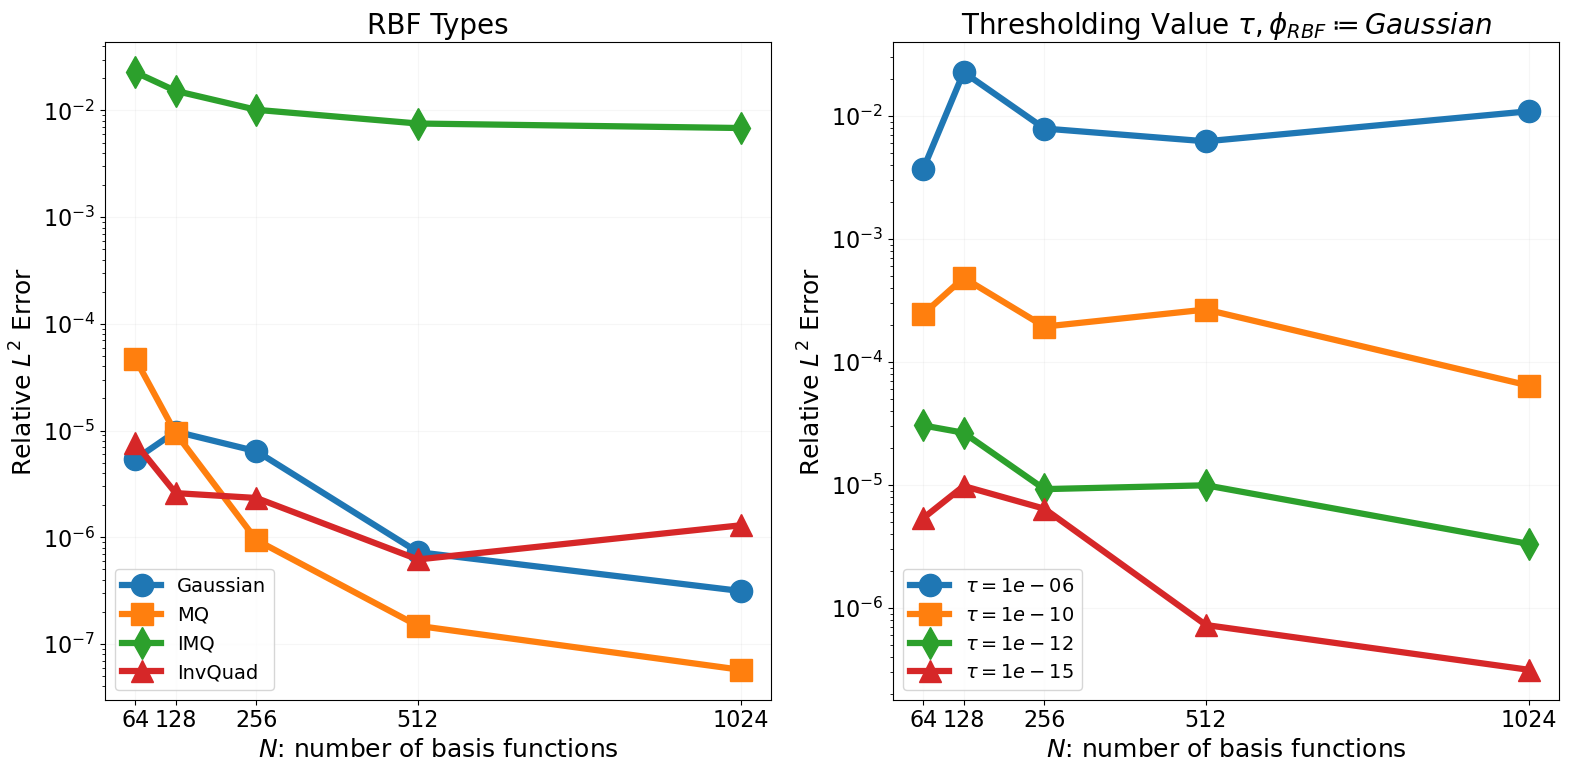

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from numba import njit

@njit
def rbf_gaussian(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.exp(-b**2 * r**2)
    return out

@njit
def d2rbf_gaussian(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = (4 * b**4 * r**2 - 2 * b**2) * np.exp(-b**2 * r**2)
    return out

@njit
def rbf_mq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.sqrt(1 + (b * r)**2)
    return out

@njit
def d2rbf_mq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1 + (b * r)**2)**(3/2)
            out[i, j] = b**2 / denom
    return out

@njit
def rbf_imq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = 1.0 / np.sqrt(1 + (b * r)**2)
    return out

@njit
def d2rbf_imq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1 + (b * r)**2)**(5/2)
            out[i, j] = b**2 * (3 * (b * r)**2 - 1) / denom
    return out

@njit
def rbf_invquad(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = 1.0 / (1 + (b * r)**2)
    return out

@njit
def d2rbf_invquad(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1 + (b * r)**2)**3
            out[i, j] = 2 * b**2 * (3 * (b * r)**2 - 1) / denom
    return out

def solver_rbf(N, rbf_func, d2rbf_func, tau=1e-15, beta=1e4):
    T = 2
    M = T * N
    c_val = 0.134
    b = c_val * np.sqrt(N)

    a1, a2 = -1.0, -1.5

    x = np.linspace(0, 1, M)
    centers = np.linspace(0, 1, N)
    dx = x[1] - x[0]

    u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1
    f = lambda x: np.pi**2 * np.sin(np.pi * x)
    rhs = f(x)

    Phi_raw = rbf_func(x, centers, b)
    Phi = Phi_raw / np.sqrt(N)

    D2Phi = d2rbf_func(x, centers, b) / np.sqrt(N)
    A1 = D2Phi.T @ D2Phi * dx
    r_vec = -D2Phi.T @ rhs * dx

    x_bdry = np.array([0.0, 1.0])
    Phi_bdry = rbf_func(x_bdry, centers, b) / np.sqrt(N)
    g_bdry = u_true(x_bdry)

    A3 = np.sqrt(beta / 2) * Phi_bdry
    r3 = np.sqrt(beta / 2) * g_bdry

    A_total = A1 + A3.T @ A3
    b_total = r_vec + A3.T @ r3

    U, S, VT = svd(A_total)
    S_inv = np.where(S > tau * np.max(S), 1/S, 0)
    w_tau = VT.T @ (S_inv * (U.T @ b_total))

    u_hat_tau = Phi @ w_tau
    u_exact = u_true(x)
    return np.linalg.norm(u_hat_tau - u_exact) / np.linalg.norm(u_exact) ** 2

# Benchmarking RBF types
N_values = [64, 128, 256, 512, 1024]
rbf_types = {
    'Gaussian': (rbf_gaussian, d2rbf_gaussian),
    'MQ': (rbf_mq, d2rbf_mq),
    'IMQ': (rbf_imq, d2rbf_imq),
    'InvQuad': (rbf_invquad, d2rbf_invquad)
}

errors_rbf = {name: [] for name in rbf_types}

for N in N_values:
    for name, (func, d2func) in rbf_types.items():
        err = solver_rbf(N, func, d2func)
        errors_rbf[name].append(err)

# Benchmarking tau for Gaussian RBF
tau_values = [1e-6, 1e-10, 1e-12, 1e-15]
errors_tau = {tau: [] for tau in tau_values}

for N in N_values:
    for tau in tau_values:
        err = solver_rbf(N, rbf_gaussian, d2rbf_gaussian, tau=tau)
        errors_tau[tau].append(err)


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4,
    "lines.markersize": 16,
    "grid.alpha": 0.1,
})



# Plot
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Left: RBF type comparison
markers = ['o', 's', 'd', '^']
for i, (name, errs) in enumerate(errors_rbf.items()):
    axs[0].plot(N_values, errs,'-',label=name, linewidth=4.5, marker=markers[i])
axs[0].set_xticks(N_values)
axs[0].set_yscale('log')
axs[0].set_title(r'Radial Basis Function Comparison', fontsize=20)
axs[0].set_xlabel(r'$N$: number of basis functions', fontsize=18)
axs[0].set_ylabel(r'Relative $L^2$ Error', fontsize=18)
axs[0].tick_params(labelsize=16)
axs[0].grid(True)
axs[0].legend(fontsize=14)

# Right: Tau sensitivity for Gaussian
for i, (tau, errs) in enumerate(errors_tau.items()):
    axs[1].plot(N_values, errs,'-',label=fr"$\tau = {tau:.0e}$", linewidth=4.5, marker=markers[i % len(markers)])
axs[1].set_xticks(N_values)
axs[1].set_yscale('log')
axs[1].set_title(r'Thresholding Value $\tau, \phi_{RBF} \coloneq Gaussian$', fontsize=20)
axs[1].set_xlabel(r'$N$: number of basis functions', fontsize=18)
axs[1].set_ylabel(r'Relative $L^2$ Error', fontsize=18)
axs[1].tick_params(labelsize=16)
axs[1].grid(True)
axs[1].legend(fontsize=14)

plt.tight_layout()
plt.savefig('fig3_poisson.png')
